# Layer 3 (PFF): would the pass actually arrive?

If a passer plays the ball to where they think an unseen teammate is (the LSTM's predicted position), would the pass actually get there and reach the teammate?

The StatsBomb freeze frame is a single snapshot without velocities, so it cannot answer this. The PFF tracking can. At the moment of each pass it gives every player's position, and comparing with 0.2 s earlier gives their velocity.

**The model.** A ground pass from the passer to a target point *arrives* when both of these hold:

1. **The path is clear.** No defender can reach any point on the ball's straight path before the ball does. The path is checked every metre, target included.
2. **The teammate gets there first.** The intended teammate can reach the target before any defender can.

Players move as in Spearman et al. (2017), a standard model in football tracking research. A player keeps their current velocity for a reaction time of 0.7 s, then runs straight to the point at up to 7 m/s. The ball travels at a constant speed. The main speed is 12.5 m/s, close to the median average speed of completed StatsBomb ground passes (section 1). 10, 15 and 20 m/s are also computed.

**A worked example.**

- A pass of 20 m at 12.5 m/s takes 1.6 s to arrive.
- A defender 6 m from the passing lane, standing still, needs 0.7 s (reaction) + 6 / 7 = 1.56 s to reach the nearest point of the lane. The ball passes that point after only about 0.8 s, so the defender is too late there.
- At the target, though, the defender may beat the teammate. Suppose the defender is 9 m away and the teammate 14 m away. The defender needs 0.7 + 9 / 7 = 1.99 s and the teammate 0.7 + 14 / 7 = 2.7 s.
- Result: the path is clear, but the teammate arrives late, so the pass does not arrive.

**What is checked.**

- **Section 3:** the model is validated on real passes, where the outcome (completed or not) is known.
- **Section 4:** it answers point 1b for unseen teammates, comparing a pass to the LSTM's predicted position with a pass to where the teammate really was.
- **Section 5:** the sensitivity of that answer to the model's settings.
- **Section 6:** the same check is applied to the better options flagged in RQ2.

The helper code is in `src/reach.py` (pass check per match) and `src/pff.py` (tracking frames and the motion model).

In [1]:
# shared figure settings used in every notebook:
# colours (navy, green, grey and light blue) and one folder for every saved figure
import matplotlib.pyplot as plt
from cycler import cycler
from pathlib import Path
plt.rcParams['axes.prop_cycle'] = cycler(color=['#1E2761', '#2C5F2D', '#9AA0A6', '#7F8FC0'])

FIGURES = Path('../data/results/figures')
FIGURES.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    """Save a figure to the shared figures folder, in the same format in every notebook."""
    fig.savefig(FIGURES / name, dpi=200, bbox_inches='tight', facecolor='white')
    print(f"saved {FIGURES / name}")


import sys, os, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join('..', 'src'))
import importlib
import pff, reach
importlib.reload(pff)
importlib.reload(reach)

RESULTS = Path('../data/results')
REACH_DIR = RESULTS / 'pff_reach'
REACH_DIR.mkdir(parents=True, exist_ok=True)

links = pd.read_pickle(RESULTS / 'pff_pass_links.pkl')
pff_all = pd.read_pickle(RESULTS / 'pff_passes_all.pkl')
tm = pd.read_pickle(RESULTS / 'pff_teammates_at_passes.pkl')
lstm_pff = pd.read_pickle(RESULTS / 'rq3_lstm_vs_pff.pkl')
pl = pd.read_pickle(RESULTS / 'rq2_risk_context_pass_level.pkl')
analysed_ids = set(pl['original_event_id'])
meta = pff.load_metadata().set_index('pff_game_id')
wc_ids = sorted(links['match_id'].unique())
print(len(wc_ids), 'matches,', len(links), 'linked passes,', len(lstm_pff), 'unseen teammates with an LSTM prediction')

64 matches, 61635 linked passes, 92847 unseen teammates with an LSTM prediction


## 1. How fast does a pass travel?

StatsBomb gives each pass a length and a duration (from the pass to the next event, usually the receipt). For completed open-play ground passes, length divided by duration is the average ball speed. Its median sets the main speed of the model.

In [2]:
rows = []
for mid in wc_ids:
    e = pd.read_pickle(Path('../data/statsbomb_cache') / f'events_{mid}.pkl')
    rows.append(e.loc[e['type'] == 'Pass', ['pass_length', 'duration', 'pass_height', 'pass_outcome', 'pass_type']])
sbp = pd.concat(rows)
g = sbp[(sbp['pass_height'] == 'Ground Pass') & sbp['pass_outcome'].isna() & sbp['pass_type'].isna()
        & (sbp['duration'] > 0)].copy()
g['length_m'] = g['pass_length'] * 0.9144
g['speed'] = g['length_m'] / g['duration']
g['length_band'] = pd.cut(g['length_m'], [0, 10, 20, 30, 60], labels=['0-10 m', '10-20 m', '20-30 m', '30+ m'])
print(f"{len(g)} completed open-play ground passes, median average speed {g['speed'].median():.1f} m/s")
print(g.groupby('length_band', observed=True)['speed'].describe()[['count', '25%', '50%', '75%']].round(1))

42285 completed open-play ground passes, median average speed 12.1 m/s
               count   25%   50%   75%
length_band                           
0-10 m        9168.0   6.7   8.5  10.6
10-20 m      21089.0  10.0  11.9  14.2
20-30 m       9500.0  12.5  14.7  17.3
30+ m         2522.0  13.8  16.2  19.0


**What this shows:** completed ground passes travel at a median average of 12.1 m/s (42285 passes). Longer passes are hit harder:

| Pass length | Median average speed |
|---|---|
| Under 10 m | 8.5 m/s |
| 10 to 20 m | 11.9 m/s |
| 20 to 30 m | 14.7 m/s |
| Over 30 m | 16.2 m/s |

The model uses one constant speed for simplicity. 12.5 m/s matches the typical pass, and 10 to 20 m/s covers the range. These averages include the receiving touch, so the true ball speed in flight is a little higher. That is one reason to check the faster settings too.

## 2. Running the check for every match

For each match this reads the tracking frames at every linked pass (and 0.2 s before, for velocities), then checks:

- every linked pass, completed or not, for validation;
- every freeze-frame teammate at an analysed pass: a pass to their true PFF position and to their freeze-frame position;
- every unseen teammate with an LSTM prediction: a pass to the predicted position.

Results are saved per match in `data/results/pff_reach/`.

In [3]:
t0 = time.time()
for i, mid in enumerate(wc_ids):
    out_path = REACH_DIR / f'reach_{mid}.pkl'
    if out_path.exists():
        continue
    lm = links[links['match_id'] == mid]
    gid = int(lm['pff_game_id'].iloc[0])
    ev = pd.read_pickle(Path('../data/statsbomb_cache') / f'events_{mid}.pkl').set_index('id')
    real, mates, unseen = reach.process_match(
        mid, lm, pff_all[pff_all['pff_game_id'] == gid], ev,
        tm[tm['match_id'] == mid], lstm_pff[lstm_pff['match_id'] == mid],
        analysed_ids, pff.load_roster(gid), meta.loc[gid, 'fps'])
    pd.to_pickle({'real': real, 'mates': mates, 'unseen': unseen}, out_path)
    print(f'[{i + 1}/{len(wc_ids)}] match {mid}: {len(real)} passes, {len(mates)} teammates, '
          f'{len(unseen)} unseen ({time.time() - t0:.0f}s)')

parts = [pd.read_pickle(REACH_DIR / f'reach_{mid}.pkl') for mid in wc_ids]
real = pd.concat([p['real'] for p in parts], ignore_index=True)
mates = pd.concat([p['mates'] for p in parts], ignore_index=True)
unseen = pd.concat([p['unseen'] for p in parts], ignore_index=True)
print(f'{len(real)} real passes, {len(mates)} freeze-frame teammates, {len(unseen)} unseen teammates with a prediction')

61063 real passes, 225600 freeze-frame teammates, 92580 unseen teammates with a prediction


## 3. Validation: does the model recognise passes that failed?

Every linked pass, completed or not, is checked from the passer to where StatsBomb says it ended. A completed pass should mostly have a clear path, and a failed one should often not. The path margin (defender time minus ball time at the closest call) is scored with:

- **AUC:** the chance that a random completed pass has a larger margin than a random failed one;
- **balanced accuracy:** of "clear path" as a prediction of completion.

The receiver condition is left out here, because a failed pass often has no recorded intended receiver.

In [4]:
def auc(y, s):
    y = np.asarray(y, bool)
    s = np.asarray(s, float)
    keep = ~np.isnan(s)
    y, s = y[keep], s[keep]
    r = pd.Series(s).rank().to_numpy()
    n1, n0 = float(y.sum()), float((~y).sum())   # floats: the integer product overflows on 60000 passes
    return (r[y].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)


print(f"{len(real)} passes, {real['complete'].mean():.1%} completed")
rows = []
for v in reach.SPEEDS:
    m = real[f'margin_v{v:g}']
    c = real['complete']
    rows.append({'ball speed (m/s)': v, 'AUC': auc(c, m),
                 'clear | completed': (m[c] > 0).mean(), 'blocked | failed': (m[~c] <= 0).mean(),
                 'balanced accuracy': ((m[c] > 0).mean() + (m[~c] <= 0).mean()) / 2})
print(pd.DataFrame(rows).round(3).to_string(index=False))

print()
print('by pass height (12.5 m/s):')
print(real.groupby('height').apply(lambda d: pd.Series({
    'passes': len(d), 'completed': d['complete'].mean(), 'AUC': auc(d['complete'], d['margin_v12.5']),
    'clear | completed': (d.loc[d['complete'], 'margin_v12.5'] > 0).mean(),
    'blocked | failed': (d.loc[~d['complete'], 'margin_v12.5'] <= 0).mean()}), include_groups=False).round(3))
print()
print(f"decisive defender tracked on camera (VISIBLE): {real['decisive_defender_visible'].mean():.1%}")

61063 passes, 83.3% completed


 ball speed (m/s)   AUC  clear | completed  blocked | failed  balanced accuracy
             10.0 0.768              0.741             0.667              0.704
             12.5 0.787              0.841             0.574              0.708
             15.0 0.797              0.890             0.493              0.691
             20.0 0.806              0.939             0.362              0.650

by pass height (12.5 m/s):
              passes  completed    AUC  clear | completed  blocked | failed
height                                                                     
Ground Pass  45326.0      0.932  0.727              0.890             0.339
High Pass     9753.0      0.460  0.634              0.385             0.792
Low Pass      5984.0      0.697  0.640              0.835             0.342

decisive defender tracked on camera (VISIBLE): 80.5%


**What this shows**

**The model recognises failed passes.** Over 61063 linked passes (83.3 percent completed), the path margin separates completed from failed passes with an AUC of 0.77 to 0.81 at every ball speed. At the main speed of 12.5 m/s:

- 84.1 percent of completed passes have a clear path;
- 57.4 percent of failed passes are blocked.

Balanced accuracy is highest at 10 to 12.5 m/s (0.704 and 0.708), so the main speed is also the best-calibrated one.

**Ground passes are where the model applies.** For ground passes the AUC is 0.727, with 89.0 percent of completed ones clear. The model assumes the ball stays on the ground, so it treats lofted balls as cuttable by any defender under the path. That is why it calls only 38.5 percent of completed high passes clear. A ground pass is the conservative case: some counterfactual passes it rejects could be played over a defender.

**Off-camera estimates matter little.** The defender who decides the check (the closest call) was tracked on camera in 80.5 percent of passes.

## 4. Passes to unseen teammates

For every unseen teammate (outside the passer's cone) who has an LSTM prediction and was tracked on camera by PFF, two passes are checked at the moment of the real pass:

- to the **LSTM's predicted position**, where a passer relying on memory would aim;
- to the teammate's **true position** (PFF), the best a passer with perfect knowledge could do.

In both cases the receiver is the real teammate, moving from where they really were. A pass to the predicted spot can fail in two ways: a defender cuts the path, or the teammate cannot get to the spot before a defender.

In [5]:
S = '12.5'
print(f'{len(unseen)} unseen teammates')
print()
summary = pd.DataFrame({
    'arrives': [unseen[f'arr_lstm_v{S}'].mean(), unseen[f'arr_true_v{S}'].mean()],
    'path clear': [unseen['path_lstm'].mean(), unseen['path_true'].mean()],
    'teammate beaten to the spot': [unseen['mate_late_lstm'].mean(), unseen['mate_late_true'].mean()],
}, index=['to LSTM prediction', 'to true position']).round(3)
print(summary)
print()
print('agreement (rows: pass to true position arrives; columns: pass to LSTM prediction arrives):')
print(pd.crosstab(unseen[f'arr_true_v{S}'], unseen[f'arr_lstm_v{S}'], normalize='all').round(3))
ok_true = unseen[unseen[f'arr_true_v{S}']]
print()
print(f"when a pass to the true position would arrive, a pass to the LSTM prediction also arrives "
      f"{ok_true[f'arr_lstm_v{S}'].mean():.1%} of the time")

92580 unseen teammates

                    arrives  path clear  teammate beaten to the spot
to LSTM prediction    0.346       0.475                        0.351
to true position      0.469       0.488                        0.059

agreement (rows: pass to true position arrives; columns: pass to LSTM prediction arrives):
arr_lstm_v12.5  False  True 
arr_true_v12.5              
False           0.496  0.035
True            0.159  0.311

when a pass to the true position would arrive, a pass to the LSTM prediction also arrives 66.2% of the time


**What this shows**

**A pass aimed at the LSTM's predicted position arrives less often than one aimed at where the teammate really is.** Over 92580 unseen teammates:

| Pass aimed at | Arrives | Path clear | Teammate beaten to the spot |
|---|---|---|---|
| LSTM prediction | 34.6% | 47.5% | 35.1% |
| True position | 46.9% | 48.8% | 5.9% |

**The difference is almost entirely at the receiving end.** The path to the predicted spot is about as clear as the path to the true position, because the two spots are close together. But when the ball arrives where the passer thinks the teammate is, the real teammate is a few metres away. A defender can often get there first: 35.1 percent of the time, against 5.9 percent when aiming at the teammate's real position.

**Memory keeps about two thirds of the passes that full knowledge would complete.**

- Of the passes that would arrive if aimed at the true position, 66.2 percent would also arrive if aimed at the prediction.
- Overall, both versions arrive for 31.1 percent of these teammates and neither for 49.6 percent.
- Only the true-position version arrives for 15.9 percent, and only the predicted version for 3.5 percent.

**In short:** a pass played from memory can be attempted and often would arrive. But it loses about a third of the passes that perfect knowledge would complete, mostly because the teammate is not quite where the passer thinks.

**Does memory feasibility mean the pass would arrive?** The same comparison, split by how far the LSTM's prediction was from the teammate's true position (PFF), and by the memory-feasible label used in RQ2 and RQ3 (prediction within 4 m of the freeze-frame position).

In [6]:
unseen['error_band'] = pd.cut(unseen['err_lstm_pff'], [0, 2, 4, 6, 100], labels=['0-2 m', '2-4 m', '4-6 m', '6+ m'])
unseen['memory_feasible'] = unseen['err_lstm_360'] < 4.0


def rates(d):
    return pd.Series({'teammates': len(d),
                      'arrives at prediction': d[f'arr_lstm_v{S}'].mean(),
                      'arrives at true position': d[f'arr_true_v{S}'].mean(),
                      'ratio': d[f'arr_lstm_v{S}'].mean() / d[f'arr_true_v{S}'].mean()})


print('by LSTM error against PFF:')
print(unseen.groupby('error_band', observed=True).apply(rates, include_groups=False).round(3))
print()
print('by the memory-feasible label (LSTM within 4 m of the freeze-frame position):')
print(unseen.groupby('memory_feasible').apply(rates, include_groups=False).round(3))

by LSTM error against PFF:
            teammates  arrives at prediction  arrives at true position  ratio
error_band                                                                   
0-2 m         19386.0                  0.433                     0.470  0.921
2-4 m         33241.0                  0.394                     0.471  0.837
4-6 m         22811.0                  0.310                     0.460  0.674
6+ m          17142.0                  0.200                     0.477  0.420

by the memory-feasible label (LSTM within 4 m of the freeze-frame position):
                 teammates  arrives at prediction  arrives at true position  \
memory_feasible                                                               
False              24305.0                  0.264                     0.473   
True               68275.0                  0.375                     0.468   

                 ratio  
memory_feasible         
False            0.558  
True             0.802  


**What this shows**

**The more accurate the prediction, the more the pass behaves like a pass to the real teammate.** The ratio is how often a pass to the prediction arrives, relative to a pass to the true position:

| LSTM error against PFF | Ratio |
|---|---|
| Under 2 m | 0.92 |
| 2 to 4 m | 0.84 |
| 4 to 6 m | 0.67 |
| Over 6 m | 0.42 |

How available the teammate really is barely changes across the bands (46 to 48 percent arriving at the true position). So the drop comes from aiming at the wrong spot, not from the teammates being different.

**The memory-feasible label picks out the passes that would work.** For teammates labelled memory-feasible in RQ2 and RQ3, a pass to the prediction arrives 37.5 percent of the time, a ratio of 0.80. For the rest it arrives 26.4 percent of the time, a ratio of 0.56.

This gives the 4 m threshold a practical meaning. Below it, a pass played from memory keeps more than four fifths of its chance of arriving; above it, the chance falls quickly. That holds even though section 2 of the LSTM check showed the label is noisy when judged against PFF.

## 5. Sensitivity to the model's settings

The headline comparison under other ball speeds, reaction times and maximum running speeds. The absolute arrival rates should move with the settings. The question is whether the gap between a pass to the predicted position and a pass to the true position stays similar.

In [7]:
rows = []
for v in reach.SPEEDS:
    rows.append({'setting': f'ball {v:g} m/s', 'to LSTM prediction': unseen[f'arr_lstm_v{v:g}'].mean(),
                 'to true position': unseen[f'arr_true_v{v:g}'].mean()})
for label, (re_, vm) in reach.SENSITIVITY.items():
    rows.append({'setting': f'ball 12.5 m/s, reaction {re_} s, max speed {vm:g} m/s',
                 'to LSTM prediction': unseen[f'arr_lstm_{label}'].mean(),
                 'to true position': unseen[f'arr_true_{label}'].mean()})
sens = pd.DataFrame(rows)
sens['ratio'] = sens['to LSTM prediction'] / sens['to true position']
print(sens.round(3).to_string(index=False))
print()
print(f"decisive defender for the pass to the prediction tracked on camera: {unseen['decisive_defender_visible'].mean():.1%}")

                                       setting  to LSTM prediction  to true position  ratio
                                   ball 10 m/s               0.263             0.354  0.744
                                 ball 12.5 m/s               0.346             0.469  0.737
                                   ball 15 m/s               0.413             0.568  0.726
                                   ball 20 m/s               0.509             0.714  0.712
ball 12.5 m/s, reaction 0.5 s, max speed 7 m/s               0.295             0.390  0.757
ball 12.5 m/s, reaction 0.9 s, max speed 7 m/s               0.389             0.536  0.727
ball 12.5 m/s, reaction 0.7 s, max speed 5 m/s               0.406             0.554  0.733
ball 12.5 m/s, reaction 0.7 s, max speed 9 m/s               0.298             0.408  0.731

decisive defender for the pass to the prediction tracked on camera: 90.6%


**What this shows:** the absolute arrival rates depend on the settings:

| Setting | Arrives at prediction | Arrives at true position |
|---|---|---|
| Ball 10 m/s | 26.3% | 35.4% |
| Ball 20 m/s | 50.9% | 71.4% |

Faster balls and slower defenders give defenders less time. But the ratio between the two stays between 0.71 and 0.76 under every ball speed, reaction time (0.5 to 0.9 s) and maximum running speed (5 to 9 m/s).

So the conclusion does not depend on the settings: aiming at the remembered position keeps about three quarters of the arrivals that aiming at the true position would get. The decisive defender for the pass to the prediction was tracked on camera in 90.6 percent of cases, so off-camera estimates do not drive the result.

## 6. Seen and unseen teammates, and the better options flagged in RQ2

Two follow-up questions use the same check on every freeze-frame teammate at an analysed pass, aiming at their true position:

- Are teammates outside the cone as available as those inside it?
- Of the better options flagged in RQ2 (visible, onside, completable forward options with a higher value than the real pass), how many could actually be completed according to the tracking?

The second is compared with the xP model behind RQ2's completable filter.

In [8]:
cf = pd.read_pickle(RESULTS / 'candidates_full.pkl')[['legitimate_forward_progressive', 'xp_value']]
mates = mates.join(cf, on='cand_index')

print('pass to the true position arrives, by the passer\'s vision cone:')
print(mates.groupby('visible_cone')[[f'arr_true_v{S}', f'arr_360_v{S}']].mean().round(3)
      .rename(index={True: 'inside cone', False: 'outside cone'}))
print()
flag = mates[mates['visible_cone'] & mates['legitimate_forward_progressive']]
other = mates[mates['visible_cone'] & ~mates['legitimate_forward_progressive']]
print(f"flagged better options (RQ2): {len(flag)}")
print(f"  arrive (tracking model): {flag[f'arr_true_v{S}'].mean():.1%}  (other visible teammates: {other[f'arr_true_v{S}'].mean():.1%})")
print(f"  mean xP: {flag['xp_value'].mean():.3f}  (other visible teammates: {other['xp_value'].mean():.3f})")
print()
print('xP of flagged better options by whether the tracking model says the pass arrives:')
print(flag.groupby(f'arr_true_v{S}')['xp_value'].describe()[['count', 'mean', '50%']].round(3))
print(f"AUC of xP for the tracking-model arrival, all visible teammates: {auc(mates.loc[mates['visible_cone'], f'arr_true_v{S}'], mates.loc[mates['visible_cone'], 'xp_value']):.3f}")

# pass level: how often does a pass bypass a flagged option that the tracking model says would arrive?
wc_pl = pl[pl['original_event_id'].isin(mates['original_event_id'])]
per_pass = flag.groupby('original_event_id')[f'arr_true_v{S}'].any()
print()
print(f"analysed World Cup passes in this table: {len(wc_pl)}")
print(f"  with a flagged better option: {len(per_pass) / len(wc_pl):.1%}  (RQ2 visible rate on the same passes: {wc_pl['visible_orig'].mean():.1%})")
print(f"  with a flagged better option that would also arrive: {per_pass.sum() / len(wc_pl):.1%}")

pass to the true position arrives, by the passer's vision cone:
              arr_true_v12.5  arr_360_v12.5
visible_cone                               
outside cone           0.472          0.411
inside cone            0.502          0.427

flagged better options (RQ2): 24433
  arrive (tracking model): 37.7%  (other visible teammates: 56.1%)
  mean xP: 0.625  (other visible teammates: 0.748)

xP of flagged better options by whether the tracking model says the pass arrives:
                  count   mean    50%
arr_true_v12.5                       
False           15232.0  0.531  0.543
True             9201.0  0.782  0.873
AUC of xP for the tracking-model arrival, all visible teammates: 0.863

analysed World Cup passes in this table: 35421
  with a flagged better option: 36.6%  (RQ2 visible rate on the same passes: 37.2%)
  with a flagged better option that would also arrive: 21.1%


**What this shows**

**Unseen teammates are about as available as seen ones.** A pass to the true position would arrive for 47.2 percent of teammates outside the cone and 50.2 percent inside it. So the vision cone does not mainly hide teammates who were impossible to reach. Many of them were as open as the visible ones.

**Many of RQ2's better options are risky, and the tracking confirms it.** Of 24433 flagged better options:

- 37.7 percent would arrive by the tracking model, against 56.1 percent for other visible teammates;
- their mean xP is 0.625, against 0.748.

**The xP model behind RQ2's completable filter agrees closely with the tracking physics.** xP predicts the tracking model's arrival with an AUC of 0.863. Flagged options that would arrive have a mean xP of 0.78, against 0.53 for those that would not. Two independent methods, one from event data and one from tracking, agree on which options are realistic.

**A tracking-confirmed RQ2 rate.** On 35421 analysed World Cup passes, 36.6 percent bypass a flagged better option, close to RQ2's 37.2 percent on the same passes. When the flagged option must also pass the tracking check, 21.1 percent of passes still bypass one. This is close to the strictest risk-adjusted rate in RQ2 (23.4 percent). Even judged by player and ball movement, about one pass in five leaves unused a visible forward option that would have arrived.

## 7. Figure

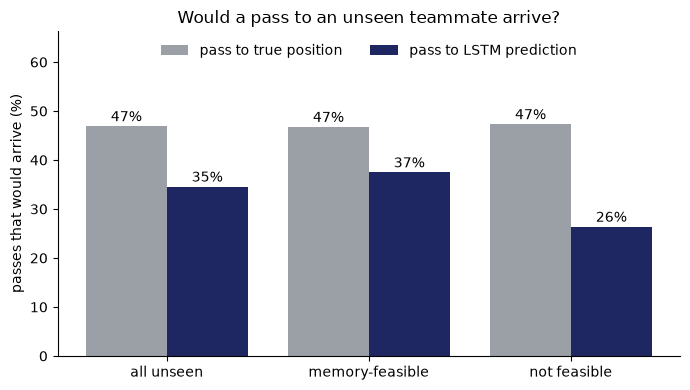

In [9]:
NAVY, GREEN, GREY = '#1E2761', '#2C5F2D', '#9AA0A6'
groups = [('all unseen', unseen),
          ('memory-feasible', unseen[unseen['memory_feasible']]),
          ('not feasible', unseen[~unseen['memory_feasible']])]
x = np.arange(len(groups))
true_r = [g[f'arr_true_v{S}'].mean() * 100 for _, g in groups]
pred_r = [g[f'arr_lstm_v{S}'].mean() * 100 for _, g in groups]
fig, ax = plt.subplots(figsize=(7, 4))
b1 = ax.bar(x - 0.2, true_r, 0.4, color=GREY, label='pass to true position')
b2 = ax.bar(x + 0.2, pred_r, 0.4, color=NAVY, label='pass to LSTM prediction')
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1, f'{b.get_height():.0f}%', ha='center', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels([n for n, _ in groups])
ax.set_ylabel('passes that would arrive (%)')
ax.set_ylim(0, max(true_r + pred_r) * 1.4)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, ncol=2, loc='upper center')
ax.set_title('Would a pass to an unseen teammate arrive?')
plt.tight_layout()
save_fig(plt.gcf(), 'rq3_pff_pass_arrival.png')
plt.show()

## 8. Save

In [10]:
real.to_pickle(RESULTS / 'rq3_reach_real_passes.pkl')
mates.to_pickle(RESULTS / 'rq3_reach_teammates.pkl')
unseen.to_pickle(RESULTS / 'rq3_reach_unseen.pkl')
print('saved rq3_reach_real_passes.pkl, rq3_reach_teammates.pkl, rq3_reach_unseen.pkl')

saved rq3_reach_real_passes.pkl, rq3_reach_teammates.pkl, rq3_reach_unseen.pkl


## Summary

**Would a pass to the predicted position actually arrive?**

**The pass-arrival model works.** It is built from the PFF tracking (positions and velocities of all players, a standard motion model, ball at 12.5 m/s). On 61063 real passes it separates completed from failed passes with an AUC of about 0.79, and it calls 84 percent of completed passes clear.

**Passes aimed from memory often work, but not as often as with full knowledge.**

- Aimed at the LSTM's predicted position, a pass to an unseen teammate would arrive 34.6 percent of the time, against 46.9 percent when aimed at the teammate's true position.
- Memory keeps about two thirds of the arrivals (66.2 percent).
- The loss happens at the receiving end: the teammate is beaten to the predicted spot 35.1 percent of the time, against 5.9 percent at their real position.
- The ratio stays between 0.71 and 0.76 under every ball speed, reaction time and running speed tested.

**Accuracy decides it.**

- With an LSTM error under 2 m, a pass to the prediction is almost as good as one to the real teammate (ratio 0.92); over 6 m it is less than half as good (0.42).
- Memory-feasible teammates keep 80 percent of their chance, the rest 56 percent. So the 4 m threshold separates passes that could be played from memory from passes that could not.

**For RQ2.**

- Teammates outside the cone are about as reachable as those inside it (47 against 50 percent).
- Flagged better options are riskier than other visible teammates (38 against 56 percent would arrive). xP agrees with the tracking physics (AUC 0.86).
- Requiring the flagged option to pass the tracking check still leaves 21.1 percent of World Cup passes bypassing a forward option that would have arrived. This is in line with RQ2's strict risk-adjusted 23.4 percent.

**Limitations.**

- The ball is assumed to travel along the ground, so lofted passes over defenders are not modelled.
- Off-camera players are positioned by PFF's estimates. They decide the outcome in only 9 to 20 percent of checks.

Saved: `rq3_reach_real_passes.pkl`, `rq3_reach_teammates.pkl`, `rq3_reach_unseen.pkl`, `figures/rq3_pff_pass_arrival.png`.